Data Wrangling II

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Create Academic Performance Dataset
data = {
  'Math_Score': [75, 80, np.nan, 65, 200, 70, 78, 82, 68, 72],
  'Reading_Score': [85, 90, 88, np.nan, 92, 87, 89, 91, 84, 86],
  'Writing_Score': [70, 75, 73, 68, 71, np.nan, 74, 76, 69, 72],
  'Placement_Score': [80, 85, 83, 78, 82, 81, 84, 86, 79, 83],
  'Placement_Offer_Count': [2, 3, 2, 1, 4, 2, 3, 3, 1, 2]
}
df = pd.DataFrame(data)

In [5]:
# --- MISSING VALUES ---
print("Missing values:\n", df.isnull().sum())

Missing values:
 Math_Score               1
Reading_Score            1
Writing_Score            1
Placement_Score          0
Placement_Offer_Count    0
dtype: int64


In [4]:
# Fill with mean
df['Math_Score'].fillna(df['Math_Score'].mean(), inplace=True)
df['Reading_Score'].fillna(df['Reading_Score'].median(), inplace=True)
df['Writing_Score'].fillna(df['Writing_Score'].mode()[0], inplace=True)
print("After filling:\n", df.isnull().sum())

After filling:
 Math_Score               1
Reading_Score            1
Writing_Score            1
Placement_Score          0
Placement_Offer_Count    0
dtype: int64


C:\Users\Kaushik Maslekar\AppData\Local\Temp\ipykernel_11684\2889581535.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Math_Score'].fillna(df['Math_Score'].mean(), inplace=True)
C:\Users\Kaushik Maslekar\AppData\Local\Temp\ipykernel_11684\2889581535.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame 

In [9]:
# --- OUTLIER DETECTION using IQR ---
Q1 = df['Math_Score'].quantile(0.25)
Q3 = df['Math_Score'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f"IQR={IQR}, Lower={lower}, Upper={upper}")
outliers = df[(df['Math_Score'] < lower) | (df['Math_Score'] > upper)]
print("Outliers:\n", outliers['Math_Score'].values)

IQR=10.0, Lower=55.0, Upper=95.0
Outliers:
 [200.]


In [ ]:
# Remove outliers
df = df[(df['Math_Score'] >= lower) & (df['Math_Score'] <= upper)]




In [13]:
# Outlier detection using Z-score
from scipy import stats
z_scores = np.abs(stats.zscore(df['Placement_Score']))
df = df[z_scores < 3]

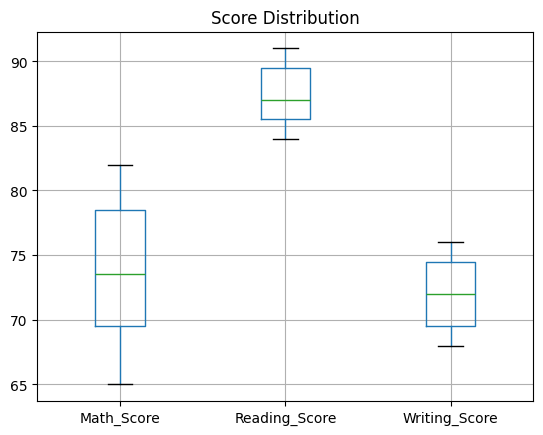

In [8]:
# Box plot to visualize
df[['Math_Score','Reading_Score','Writing_Score']].boxplot()
plt.title("Score Distribution")
plt.show()

In [9]:
# --- DATA TRANSFORMATION ---
# Log transformation to reduce skewness
df['Math_Log'] = np.log(df['Math_Score'])
print(df[['Math_Score','Math_Log']].head())

   Math_Score  Math_Log
0        75.0  4.317488
1        80.0  4.382027
3        65.0  4.174387
5        70.0  4.248495
6        78.0  4.356709
